## Exploratory Data Analysis


In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# Now import your modules
import pandas as pd
from src.config import DATABASE_URL
from sqlalchemy import create_engine

In [2]:
engine = create_engine(DATABASE_URL)
df = pd.read_sql("SELECT * FROM smard_market_data ORDER BY timestamp", engine)
df.head()

,timestamp,gen_nuclear,gen_lignite,gen_offshore_wind,gen_hydro,gen_other_conv,gen_other_renew,gen_biomass,gen_onshore_wind,gen_solar,...,cons_pumped_storage,price_de_lu,price_neighbors,price_at,proj_offshore,proj_onshore,proj_solar,proj_other,proj_wind_solar,proj_total
0,2020-05-03 22:00:00+00:00,1625.25,1788.00,132.00,492.25,386.75,49.75,1124.00,404.25,0.0,...,131.00,22.20,17.42,22.20,131.75,547.50,0.0,5800.38,679.25,6479.63
1,2020-05-03 22:15:00+00:00,1624.25,1814.00,135.00,442.25,385.00,49.75,1118.25,415.75,0.0,...,182.25,22.20,NaN,22.20,128.00,549.00,0.0,5802.63,677.00,6479.63
2,2020-05-03 22:30:00+00:00,1603.75,1817.25,140.50,428.50,383.75,49.75,1117.75,403.25,0.0,...,353.00,22.20,NaN,22.20,124.25,550.50,0.0,5804.88,674.75,6479.63
3,2020-05-03 22:45:00+00:00,1602.75,1812.25,148.25,445.50,384.25,49.75,1117.25,396.50,0.0,...,478.50,22.20,NaN,22.20,121.00,552.25,0.0,5806.38,673.25,6479.63
4,2020-05-03 23:00:00+00:00,1608.00,1781.00,145.25,463.00,385.25,49.75,1114.25,399.50,0.0,...,515.50,20.46,16.18,20.46,118.50,554.25,0.0,6041.08,672.75,6713.83


In [3]:
# size of data
df.shape

(175392, 25)

### 1. Missing Values & Imputation Strategy
We will analyze missing values per column and suggest appropriate imputation strategies based on data type and business context.

In [4]:
# Show missing values per column and data types
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': df.isnull().mean() * 100,
    'dtype': df.dtypes
})
missing_summary = missing_summary.sort_values('missing_pct', ascending=False)
display(missing_summary)

,missing_count,missing_pct,dtype
price_neighbors,131544,75.000000,float64
gen_nuclear,44202,25.201834,float64
cons_residual,3,0.001710,float64
timestamp,0,0.000000,"datetime64[us, UTC]"
gen_lignite,0,0.000000,float64
gen_other_conv,0,0.000000,float64
gen_other_renew,0,0.000000,float64
gen_offshore_wind,0,0.000000,float64
gen_hydro,0,0.000000,float64
gen_onshore_wind,0,0.000000,float64


### 2. Seasonality Analysis (Daily, Weekly, Yearly)
We will explore seasonality patterns in load, generation, and price data using time series decomposition and visualizations.

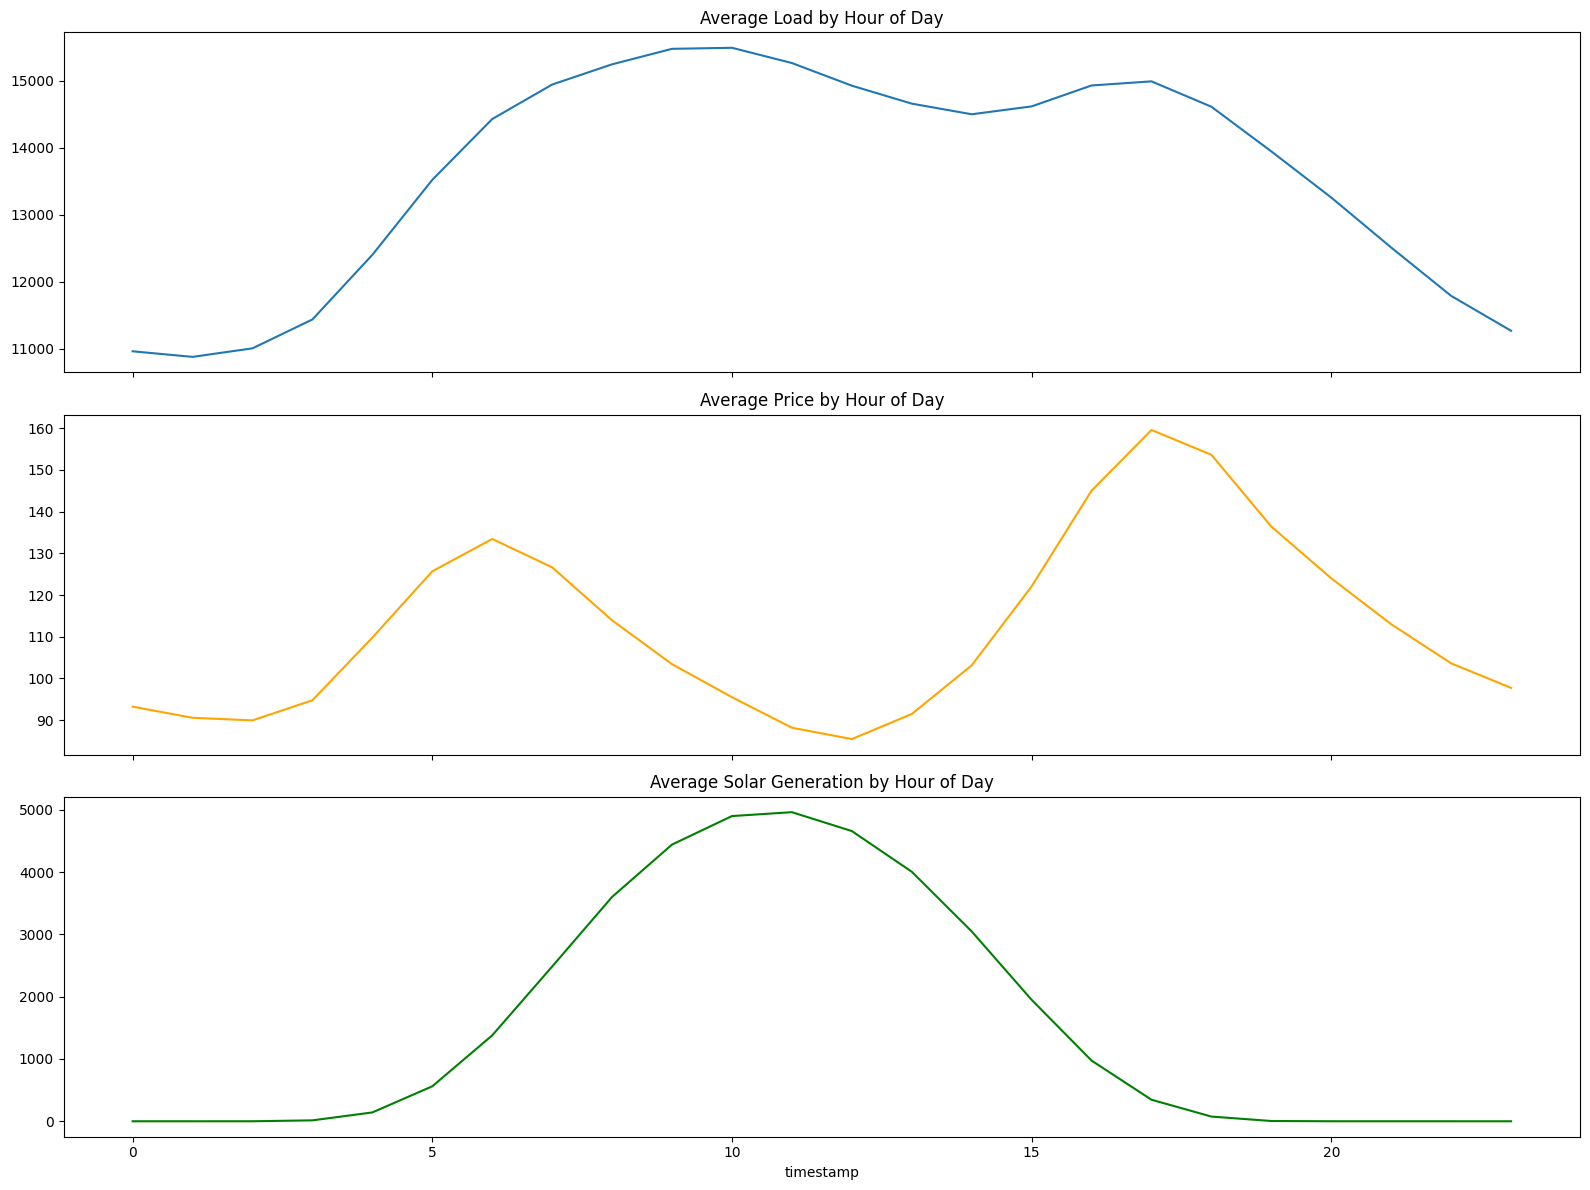

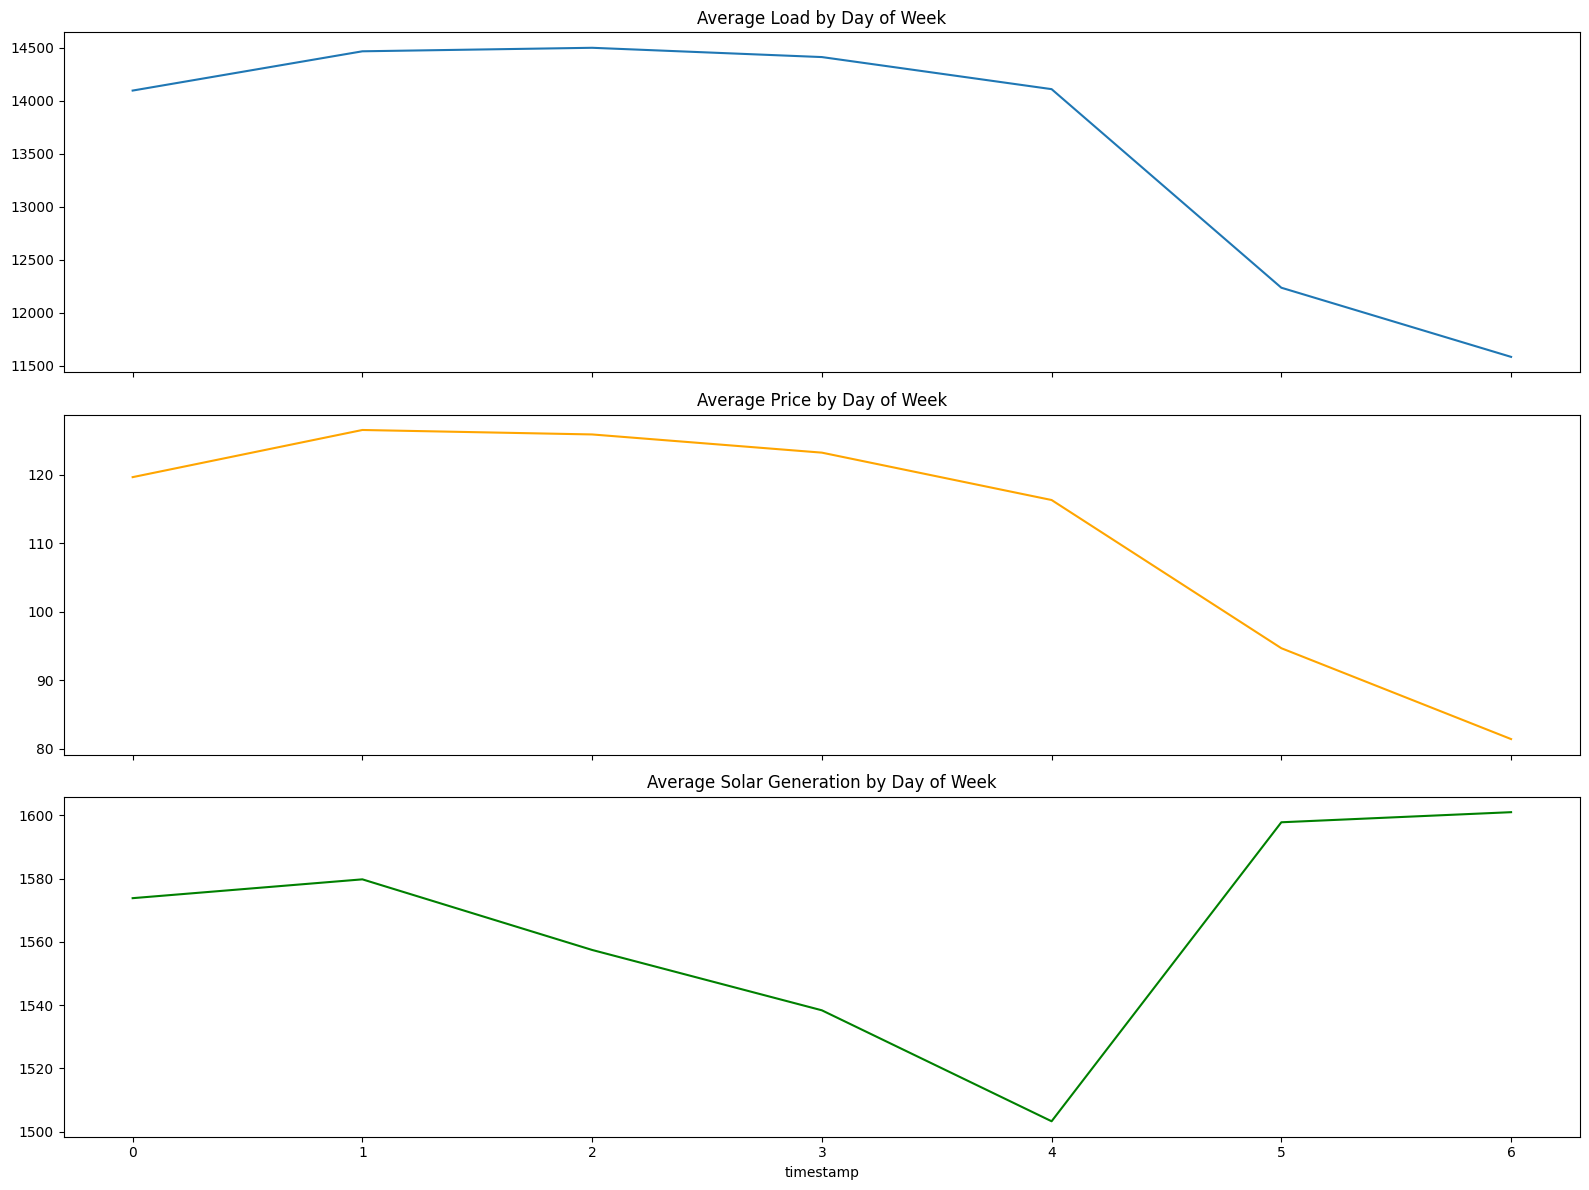

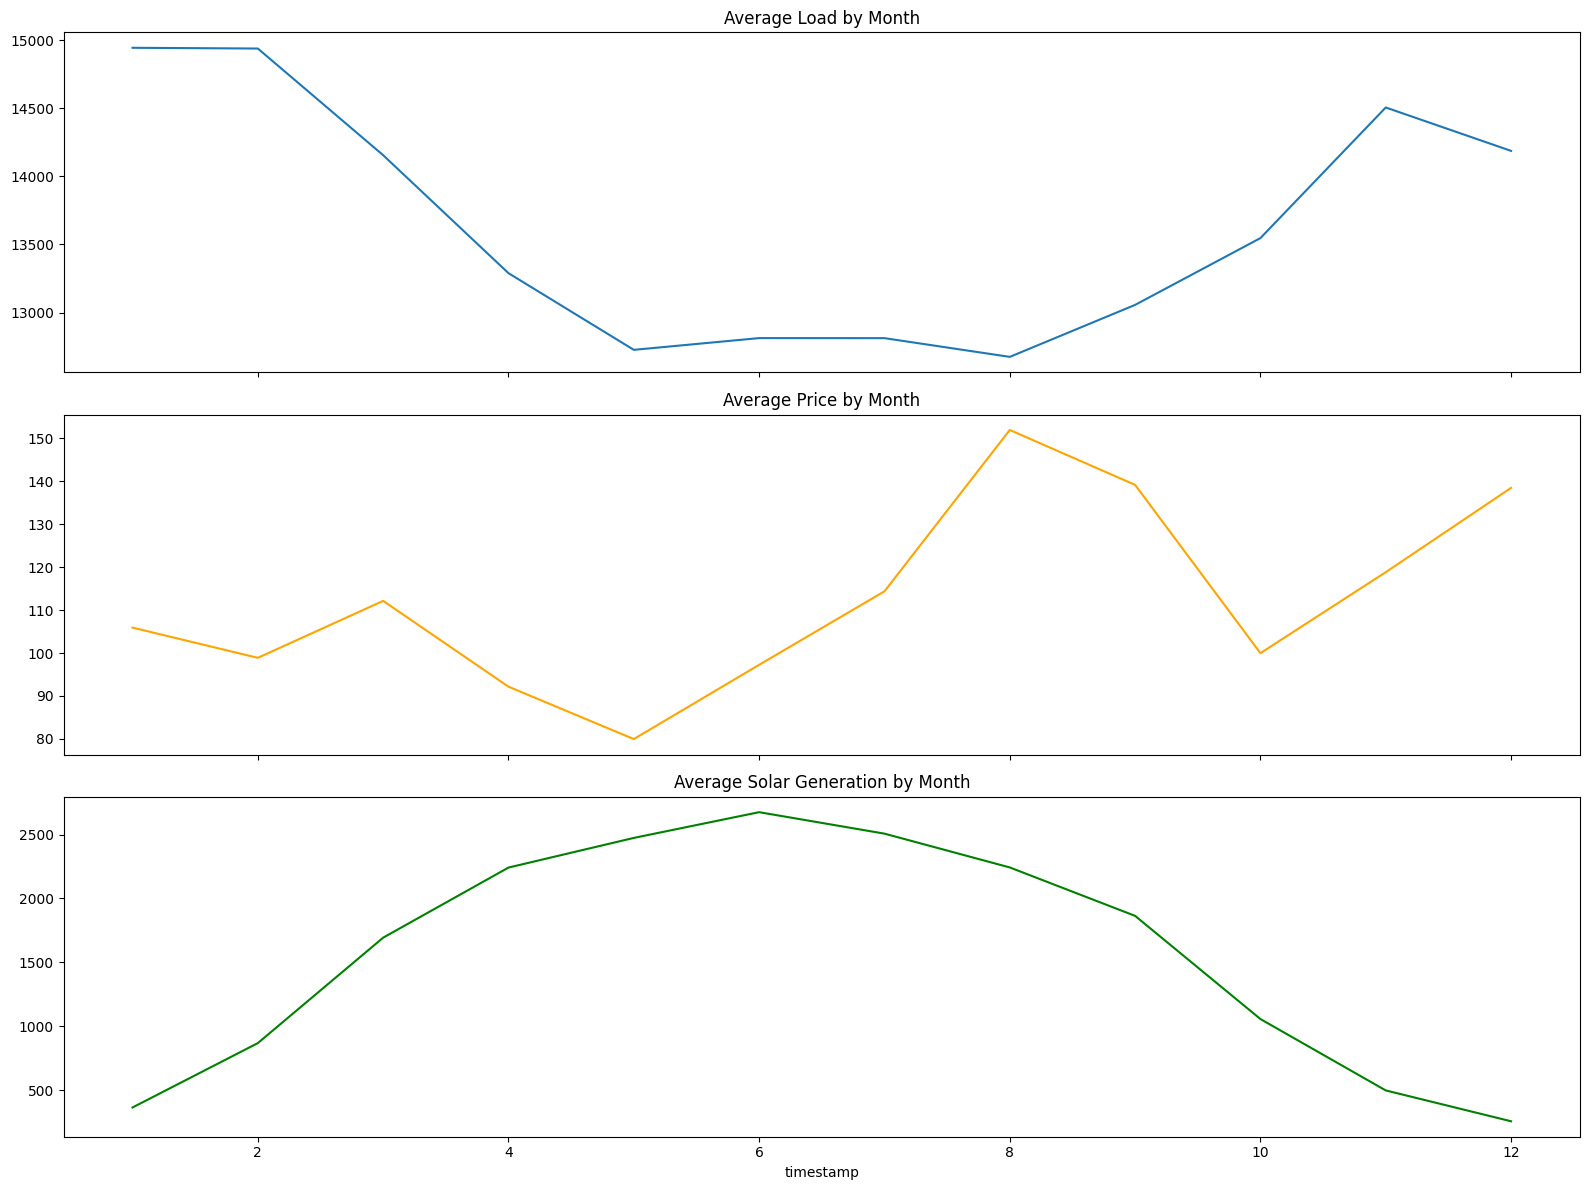

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
# Daily seasonality (hour of day)
df.groupby(df.index.hour)['cons_total_grid'].mean().plot(ax=axes[0], title='Average Load by Hour of Day')
df.groupby(df.index.hour)['price_de_lu'].mean().plot(ax=axes[1], title='Average Price by Hour of Day', color='orange')
df.groupby(df.index.hour)['gen_solar'].mean().plot(ax=axes[2], title='Average Solar Generation by Hour of Day', color='green')
plt.tight_layout()
plt.show()
# Weekly seasonality (day of week)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
df.groupby(df.index.dayofweek)['cons_total_grid'].mean().plot(ax=axes[0], title='Average Load by Day of Week')
df.groupby(df.index.dayofweek)['price_de_lu'].mean().plot(ax=axes[1], title='Average Price by Day of Week', color='orange')
df.groupby(df.index.dayofweek)['gen_solar'].mean().plot(ax=axes[2], title='Average Solar Generation by Day of Week', color='green')
plt.tight_layout()
plt.show()
# Yearly seasonality (month)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
df.groupby(df.index.month)['cons_total_grid'].mean().plot(ax=axes[0], title='Average Load by Month')
df.groupby(df.index.month)['price_de_lu'].mean().plot(ax=axes[1], title='Average Price by Month', color='orange')
df.groupby(df.index.month)['gen_solar'].mean().plot(ax=axes[2], title='Average Solar Generation by Month', color='green')
plt.tight_layout()
plt.show()

### 3. Correlation Analysis
We will examine the correlation between generation types, load, and price to identify key relationships and potential drivers.

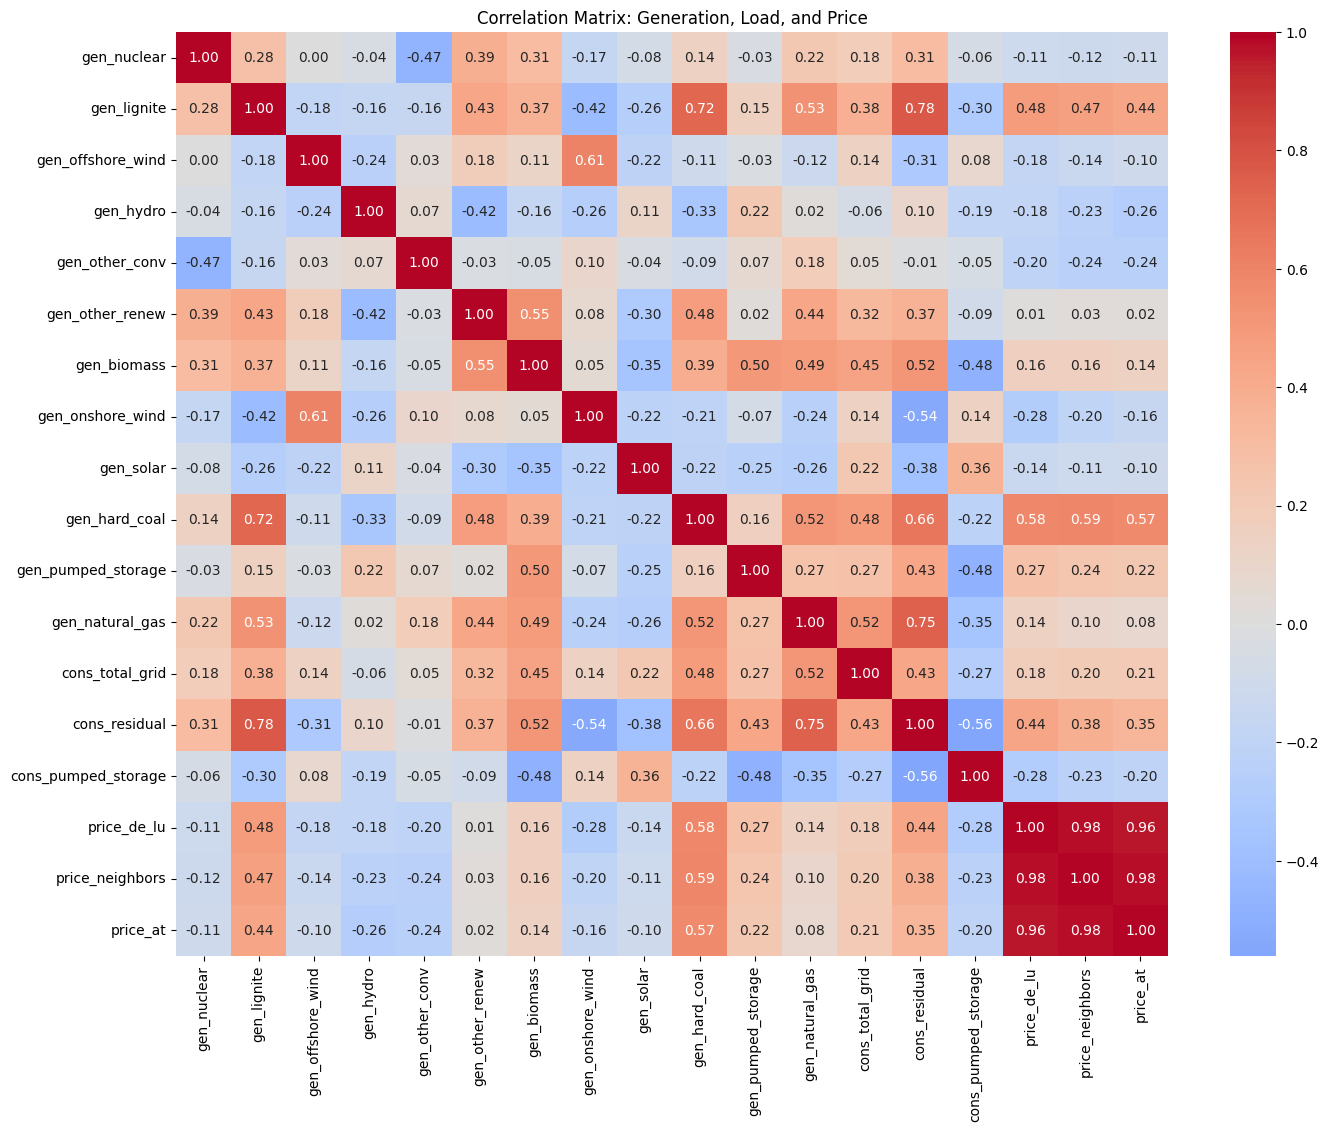

In [6]:
# Select relevant columns for correlation analysis
corr_cols = [col for col in df.columns if ('gen_' in col or 'cons_' in col or 'price' in col)]
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Generation, Load, and Price')
plt.show()

### 4. Outlier Detection (Price Spikes)
We will identify and visualize outliers in the price data, focusing on extreme spikes in the German power market.

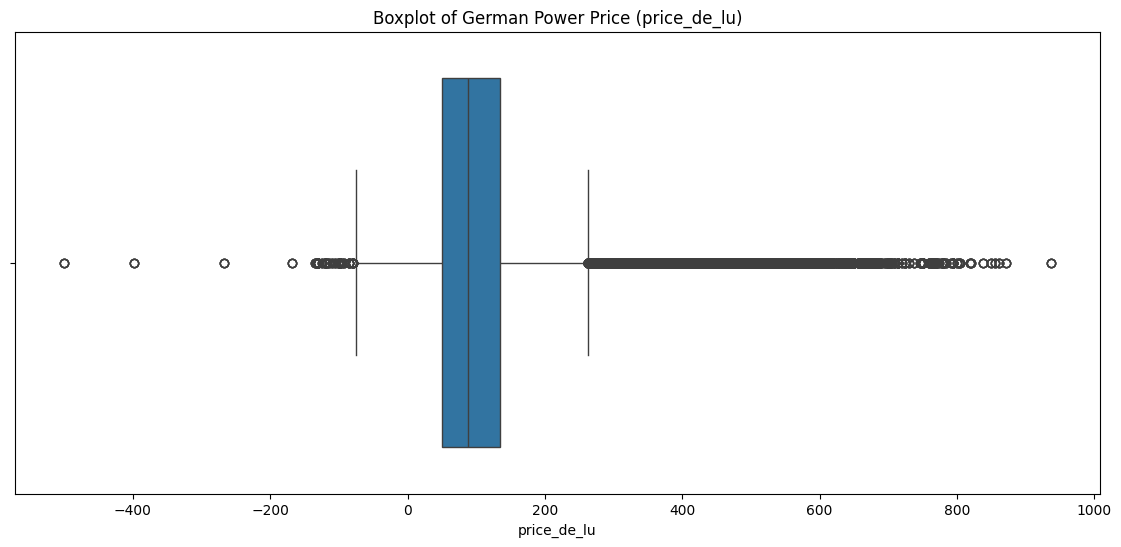

Number of price spikes above 99th percentile: 1752


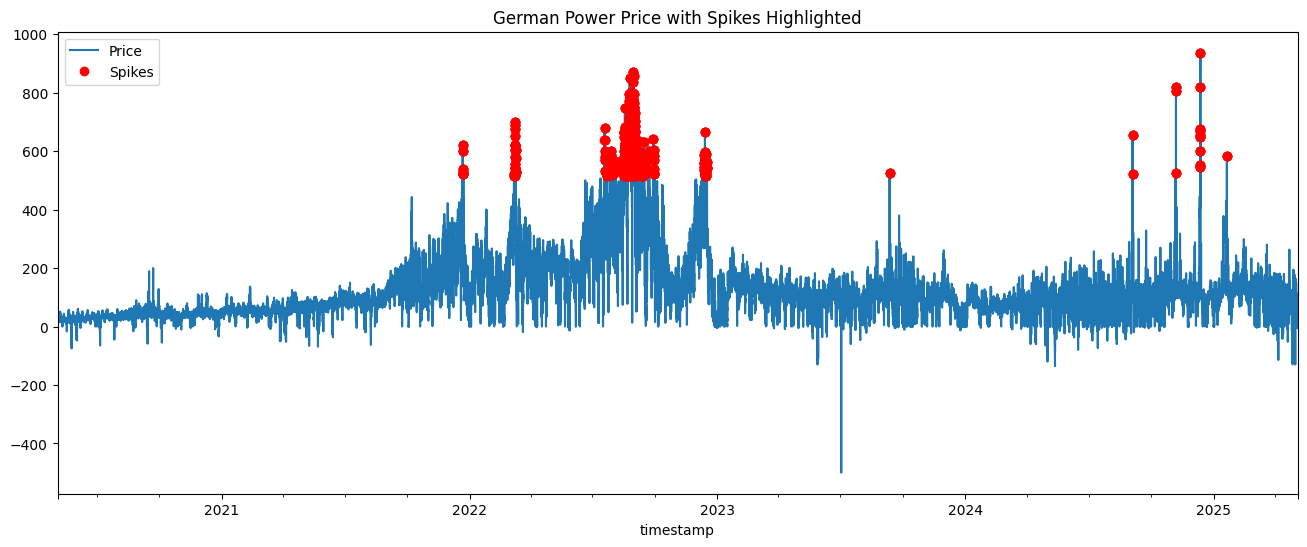

In [7]:
# Visualize price distribution and highlight outliers
plt.figure(figsize=(14, 6))
sns.boxplot(x=df['price_de_lu'])
plt.title('Boxplot of German Power Price (price_de_lu)')
plt.show()
# Identify extreme price spikes (e.g., beyond 99th percentile)
threshold = df['price_de_lu'].quantile(0.99)
spikes = df[df['price_de_lu'] > threshold]
print(f"Number of price spikes above 99th percentile: {len(spikes)}")
plt.figure(figsize=(16, 6))
df['price_de_lu'].plot(label='Price')
spikes['price_de_lu'].plot(style='o', color='red', label='Spikes')
plt.legend()
plt.title('German Power Price with Spikes Highlighted')
plt.show()

### 5. Renewable Penetration Trends Over Time
We will analyze how the share of renewable generation (wind, solar, hydro, biomass, etc.) has evolved over time.

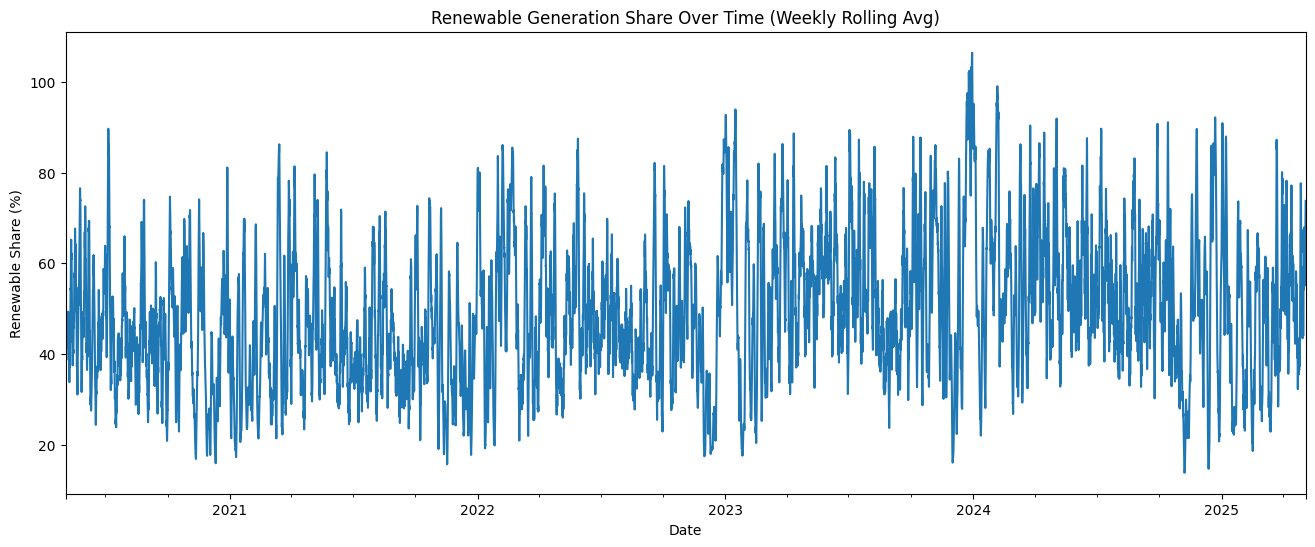

In [8]:
# Calculate renewable share over time
renewable_cols = ['gen_onshore_wind', 'gen_offshore_wind', 'gen_solar', 'gen_hydro', 'gen_biomass', 'gen_other_renew']
df['renewable_gen'] = df[renewable_cols].sum(axis=1)
df['renewable_share'] = df['renewable_gen'] / df['cons_total_grid'] * 100
plt.figure(figsize=(16, 6))
df['renewable_share'].rolling(24*7).mean().plot()  # 1-week rolling average
plt.title('Renewable Generation Share Over Time (Weekly Rolling Avg)')
plt.ylabel('Renewable Share (%)')
plt.xlabel('Date')
plt.show()

### 6. Relationship Between Forecasts (proj_*) and Actuals
We will compare forecasted values (proj_*) with actuals to assess forecast accuracy and identify systematic biases.

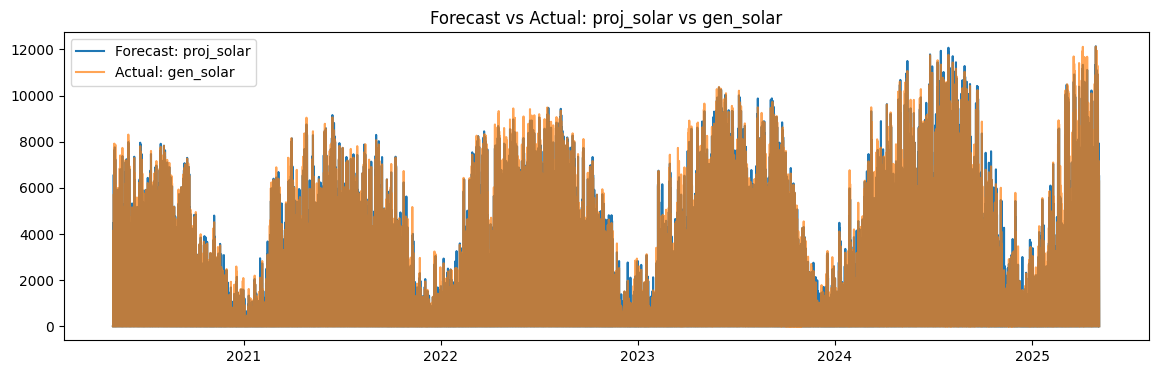

Mean Absolute Error for proj_solar vs gen_solar: 115.07


In [9]:
# Compare forecasts (proj_*) with actuals for wind and solar
import numpy as np
proj_cols = [col for col in df.columns if col.startswith('proj_')]
actual_cols = [col.replace('proj_', 'gen_') for col in proj_cols]
for proj, actual in zip(proj_cols, actual_cols):
    if actual in df.columns:
        plt.figure(figsize=(14, 4))
        plt.plot(df[proj], label=f'Forecast: {proj}')
        plt.plot(df[actual], label=f'Actual: {actual}', alpha=0.7)
        plt.title(f'Forecast vs Actual: {proj} vs {actual}')
        plt.legend()
        plt.show()
        mae = np.mean(np.abs(df[proj] - df[actual]))
        print(f'Mean Absolute Error for {proj} vs {actual}: {mae:.2f}')

### Additional EDA: Forecast Error Distribution Over Time
We will analyze the distribution and trends of forecast errors (proj_* vs gen_*) to identify periods of high/low accuracy and potential systematic biases.

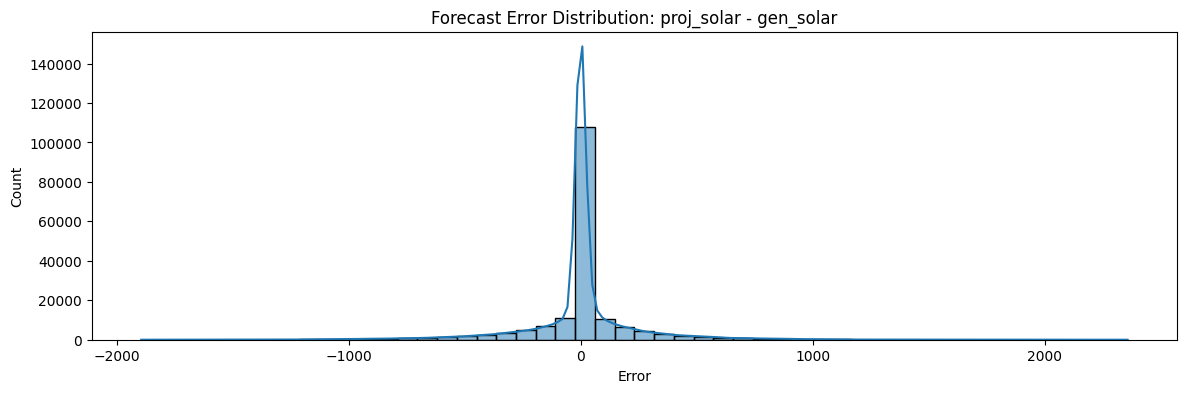

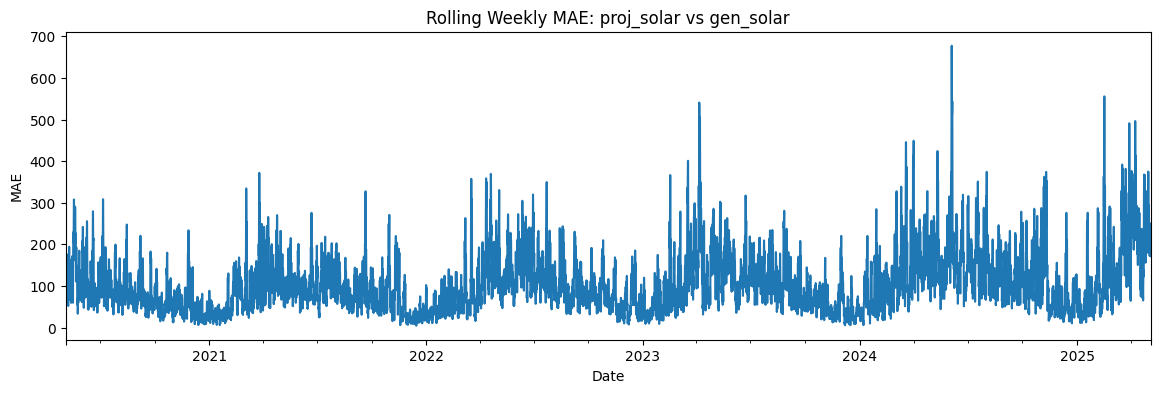

In [10]:
# Plot forecast error distribution and rolling MAE for each proj_*/gen_* pair
for proj in proj_cols:
    actual = proj.replace('proj_', 'gen_')
    if actual in df.columns:
        error = df[proj] - df[actual]
        plt.figure(figsize=(14, 4))
        sns.histplot(error.dropna(), bins=50, kde=True)
        plt.title(f'Forecast Error Distribution: {proj} - {actual}')
        plt.xlabel('Error')
        plt.show()
        # Rolling MAE
        rolling_mae = error.abs().rolling(24*7).mean()
        plt.figure(figsize=(14, 4))
        rolling_mae.plot()
        plt.title(f'Rolling Weekly MAE: {proj} vs {actual}')
        plt.ylabel('MAE')
        plt.xlabel('Date')
        plt.show()

### Extreme Event Analysis
We will identify and summarize extreme events, such as negative prices and demand peaks, which are critical for risk management and operational planning.

In [11]:
# Identify negative price events
negative_prices = df[df['price_de_lu'] < 0]
print(f"Number of negative price events: {len(negative_prices)}")
if not negative_prices.empty:
    display(negative_prices[['price_de_lu']].head())
# Identify demand peaks (top 1%)
demand_threshold = df['cons_total_grid'].quantile(0.99)
demand_peaks = df[df['cons_total_grid'] > demand_threshold]
print(f"Number of demand peak events (top 1%): {len(demand_peaks)}")
if not demand_peaks.empty:
    display(demand_peaks[['cons_total_grid']].head())

Number of negative price events: 4928


,price_de_lu
timestamp,
2020-05-11 01:00:00+00:00,-0.01
2020-05-11 01:15:00+00:00,-0.01
2020-05-11 01:30:00+00:00,-0.01
2020-05-11 01:45:00+00:00,-0.01
2020-05-17 11:00:00+00:00,-5.19


Number of demand peak events (top 1%): 1754


,cons_total_grid
timestamp,
2020-11-19 10:15:00+00:00,18659.50
2020-11-19 10:30:00+00:00,18701.75
2020-11-19 10:45:00+00:00,18763.75
2020-11-19 11:00:00+00:00,18693.25
2020-11-19 11:15:00+00:00,18673.00


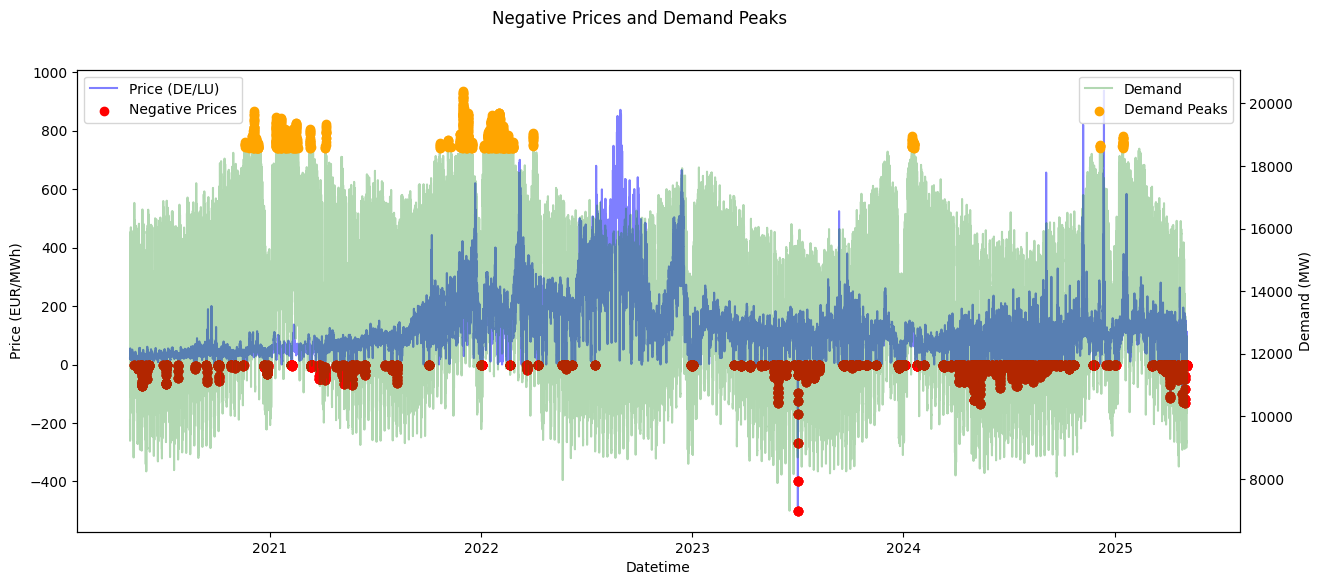

In [12]:
# Plot negative prices and demand peaks
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot price_de_lu (German power price)
x = df.index
ax1.plot(x, df['price_de_lu'], label='Price (DE/LU)', color='blue', alpha=0.5)

# Highlight negative prices
if not negative_prices.empty:
    ax1.scatter(negative_prices.index, negative_prices['price_de_lu'], color='red', label='Negative Prices', zorder=5)

# Plot demand (cons_total_grid) on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, df['cons_total_grid'], label='Demand', color='green', alpha=0.3)

# Highlight demand peaks
if not demand_peaks.empty:
    ax2.scatter(demand_peaks.index, demand_peaks['cons_total_grid'], color='orange', label='Demand Peaks', zorder=5)

ax1.set_xlabel('Datetime')
ax1.set_ylabel('Price (EUR/MWh)')
ax2.set_ylabel('Demand (MW)')

fig.suptitle('Negative Prices and Demand Peaks')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

### Data Quality & Anomaly Detection
We will check for duplicate timestamps and sudden jumps in key variables, which may indicate data quality issues or anomalies.

In [13]:
# Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicates}")
# Check for sudden jumps in price and load (simple diff threshold)
price_jumps = (df['price_de_lu'].diff().abs() > df['price_de_lu'].std() * 5).sum()
load_jumps = (df['cons_total_grid'].diff().abs() > df['cons_total_grid'].std() * 5).sum()
print(f"Number of extreme price jumps: {price_jumps}")
print(f"Number of extreme load jumps: {load_jumps}")

Number of duplicate timestamps: 0
Number of extreme price jumps: 0
Number of extreme load jumps: 0


There are no duplicate timestamps and sudden jumps in price/load—important for ensuring reliable analysis and reporting

## Lead/Lag Analysis Between Forecasts and Actuals
We will explore whether forecast errors are autocorrelated or if there is a systematic lead/lag between forecasts and actuals.

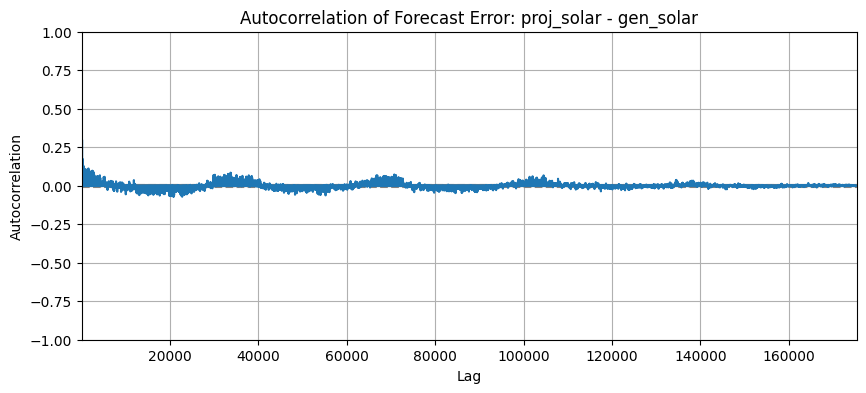

In [14]:
# Simple cross-correlation plot for each proj_*/gen_* pair
for proj in proj_cols:
    actual = proj.replace('proj_', 'gen_')
    if actual in df.columns:
        error = df[proj] - df[actual]
        plt.figure(figsize=(10, 4))
        pd.plotting.autocorrelation_plot(error.dropna())
        plt.title(f'Autocorrelation of Forecast Error: {proj} - {actual}')
        plt.show()

This is a Lead/lag analysis between forecasts and actuals, using autocorrelation plots of forecast errors. This helps identify if errors are persistent or if there’s a systematic lag—valuable for improving forecasting processes. 

## Government/Regulatory KPIs
We will now look at the following
1. Renewable Energy Share (RES %): Define as `(gen_offshore_wind + gen_onshore_wind + gen_solar + gen_hydro + gen_biomass + gen_other_renew) / cons_total_grid`. Track daily, monthly, and annual progress toward German climate targets.
2. Carbon Intensity Index (gCO2/kWh): Outline a methodology using fixed emission factors for `gen_lignite`, `gen_hard_coal`, and `gen_natural_gas` to evaluate grid decarbonization.
3. Supply Adequacy & Security: Analyze the utilization and frequency of `gen_pumped_storage` and `gen_other_conv` during peak demand periods.

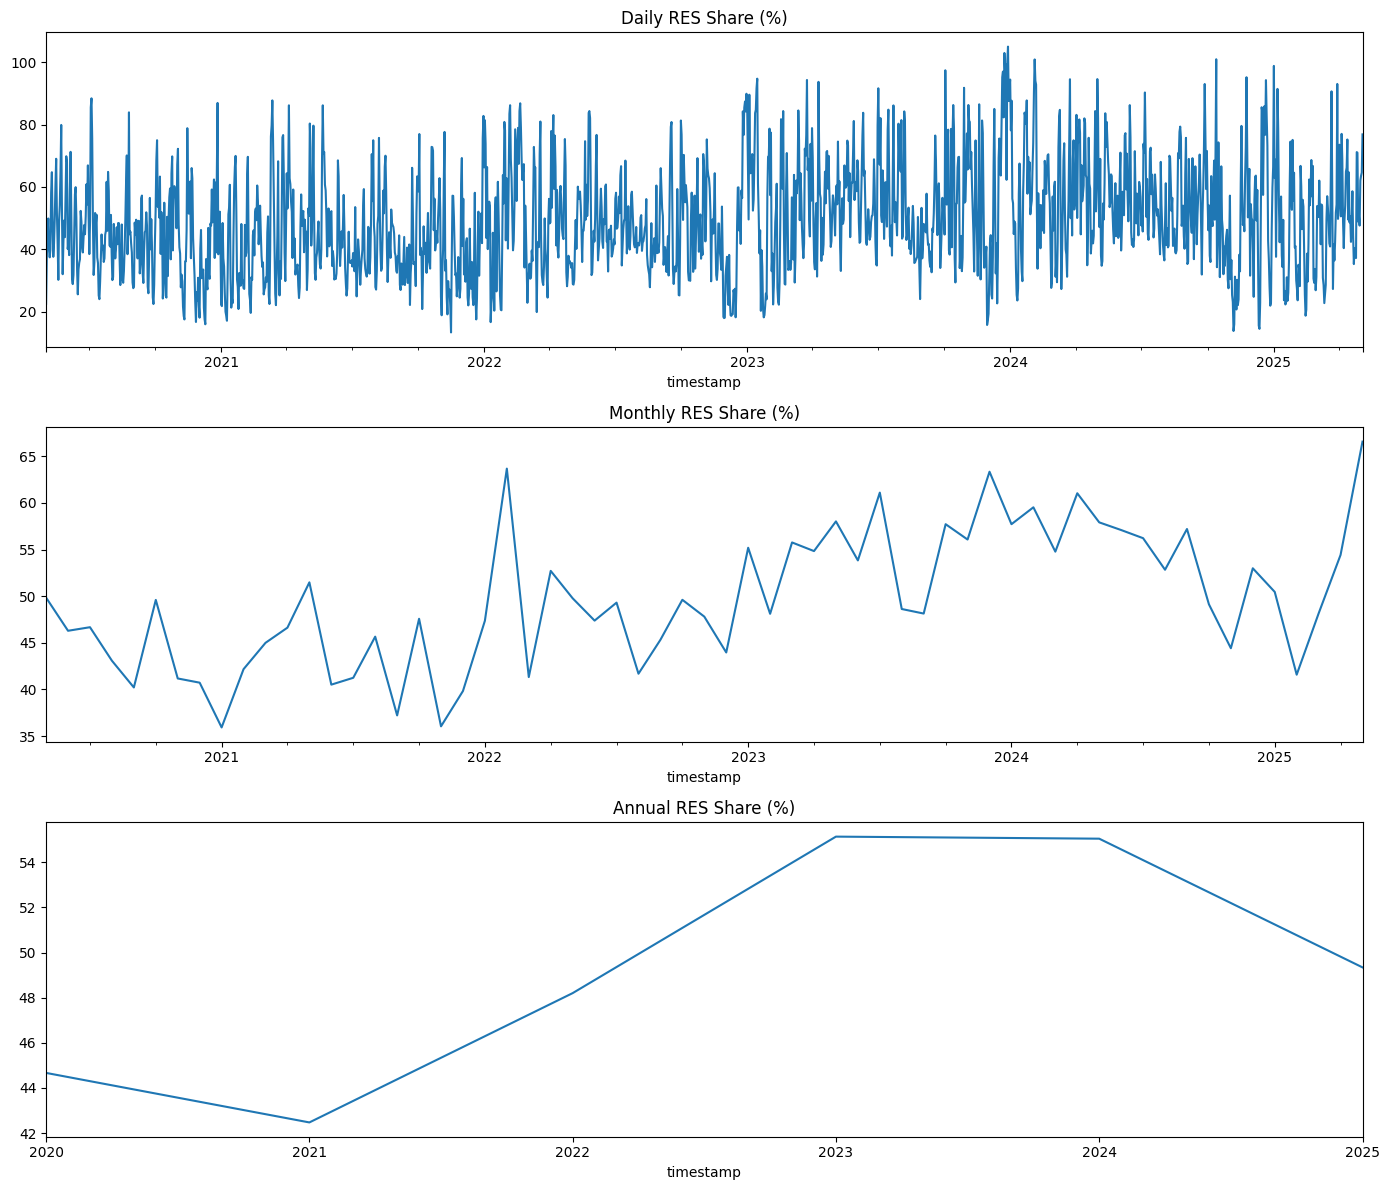

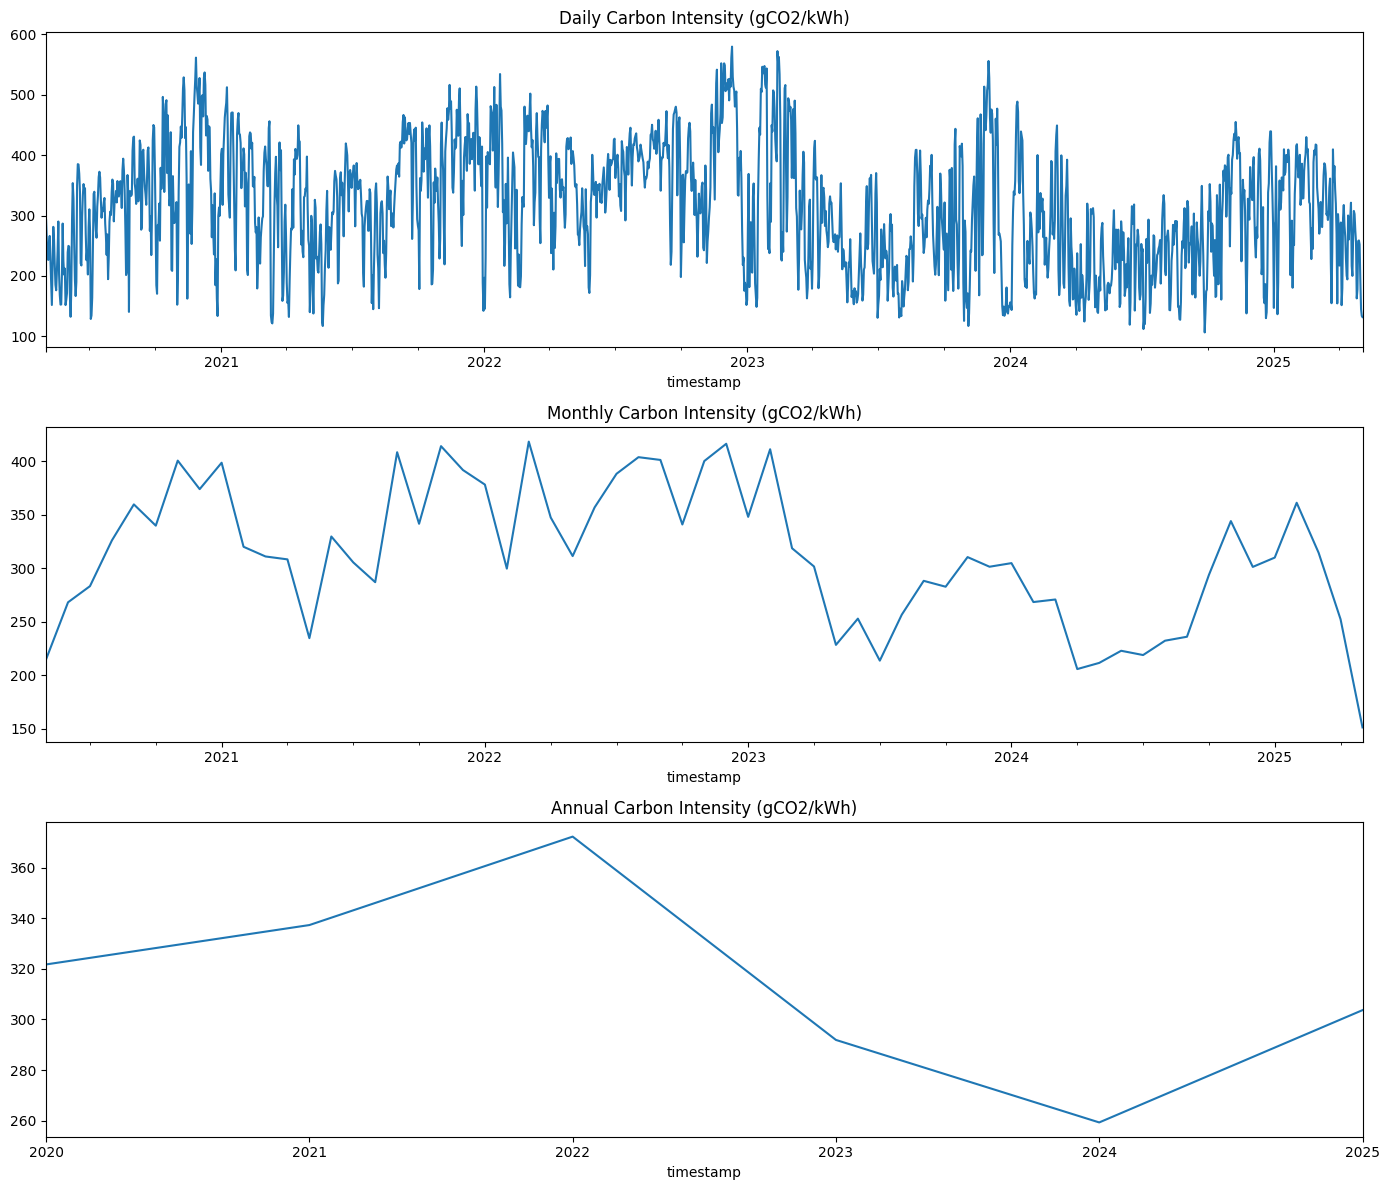

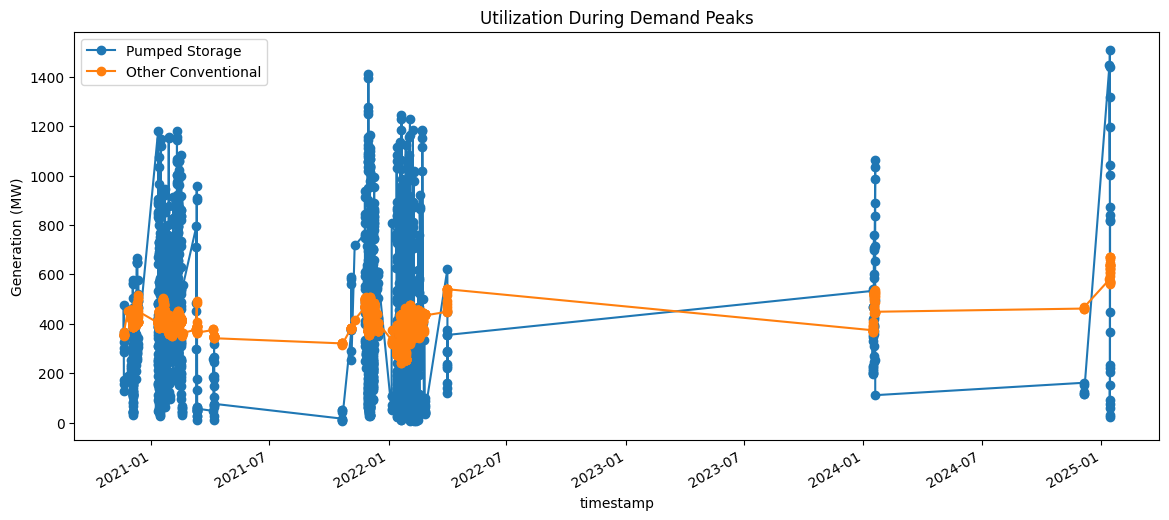

Pumped Storage used in 1754 of 1754 peak events
Other Conventional used in 1754 of 1754 peak events


In [15]:
# --- Renewable Energy Share (RES %) ---
df['res_share'] = (
    df['gen_offshore_wind'] + df['gen_onshore_wind'] + df['gen_solar'] +
    df['gen_hydro'] + df['gen_biomass'] + df['gen_other_renew']
) / df['cons_total_grid'] * 100

# Track daily, monthly, annual RES progress
daily_res = df['res_share'].resample('D').mean()
monthly_res = df['res_share'].resample('ME').mean()  # Use 'ME' for month end
annual_res = df['res_share'].resample('YE').mean()   # Use 'YE' for year end

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
daily_res.plot(ax=axes[0], title='Daily RES Share (%)')
monthly_res.plot(ax=axes[1], title='Monthly RES Share (%)')
annual_res.plot(ax=axes[2], title='Annual RES Share (%)')
plt.tight_layout()
plt.show()

# --- Carbon Intensity Index (gCO2/kWh) ---
# Emission factors (gCO2/kWh)
EF_LIGNITE = 1000
EF_HARD_COAL = 820
EF_NATURAL_GAS = 490

gen_lignite = df.get('gen_lignite', 0)
gen_hard_coal = df.get('gen_hard_coal', 0)
gen_natural_gas = df.get('gen_natural_gas', 0)

df['carbon_emissions'] = (
    gen_lignite * EF_LIGNITE +
    gen_hard_coal * EF_HARD_COAL +
    gen_natural_gas * EF_NATURAL_GAS
)
df['carbon_intensity'] = df['carbon_emissions'] / df['cons_total_grid']  # gCO2/kWh

carbon_daily = df['carbon_intensity'].resample('D').mean()
carbon_monthly = df['carbon_intensity'].resample('ME').mean()
carbon_annual = df['carbon_intensity'].resample('YE').mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
carbon_daily.plot(ax=axes[0], title='Daily Carbon Intensity (gCO2/kWh)')
carbon_monthly.plot(ax=axes[1], title='Monthly Carbon Intensity (gCO2/kWh)')
carbon_annual.plot(ax=axes[2], title='Annual Carbon Intensity (gCO2/kWh)')
plt.tight_layout()
plt.show()

# --- Supply Adequacy & Security ---
# Analyze utilization and frequency of pumped storage and other conventional during demand peaks
if not demand_peaks.empty:
    pumped_storage_util = demand_peaks['gen_pumped_storage']
    other_conv_util = demand_peaks['gen_other_conv']
    fig, ax = plt.subplots(figsize=(14, 6))
    pumped_storage_util.plot(style='o-', label='Pumped Storage')
    other_conv_util.plot(style='o-', label='Other Conventional')
    plt.title('Utilization During Demand Peaks')
    plt.ylabel('Generation (MW)')
    plt.legend()
    plt.show()
    # Frequency analysis
    print('Pumped Storage used in', (pumped_storage_util > 0).sum(), 'of', len(demand_peaks), 'peak events')
    print('Other Conventional used in', (other_conv_util > 0).sum(), 'of', len(demand_peaks), 'peak events')
else:
    print('No demand peaks detected for supply adequacy analysis.')


## Corporate & Market Player KPIs
1. Capture Prices: Define the formulas to calculate the specific capture prices for `gen_solar`, `gen_onshore_wind`, and `gen_offshore_wind` against `price_de_lu` to evaluate asset profitability.
2. Cannibalization Coefficient: Formulate the ratio of technology-specific capture price to the time-weighted average market price.
3. Forecast Accuracy (MAE/MAPE): Define metrics to evaluate `proj_total` vs. actual total generation, and `proj_wind_solar` vs. actual wind/solar generation.


In [16]:
# --- Capture Prices ---
def capture_price(gen, price):
    return (gen * price).sum() / gen.sum() if gen.sum() != 0 else float('nan')

solar_cp = capture_price(df['gen_solar'], df['price_de_lu'])
onshore_cp = capture_price(df['gen_onshore_wind'], df['price_de_lu'])
offshore_cp = capture_price(df['gen_offshore_wind'], df['price_de_lu'])
market_avg_price = df['price_de_lu'].mean()

print(f"Solar Capture Price: {solar_cp:.2f} €/MWh")
print(f"Onshore Wind Capture Price: {onshore_cp:.2f} €/MWh")
print(f"Offshore Wind Capture Price: {offshore_cp:.2f} €/MWh")
print(f"Market Average Price: {market_avg_price:.2f} €/MWh")

# --- Cannibalization Coefficient ---
solar_cannib = solar_cp / market_avg_price if market_avg_price != 0 else float('nan')
onshore_cannib = onshore_cp / market_avg_price if market_avg_price != 0 else float('nan')
offshore_cannib = offshore_cp / market_avg_price if market_avg_price != 0 else float('nan')

print(f"Solar Cannibalization Coefficient: {solar_cannib:.3f}")
print(f"Onshore Wind Cannibalization Coefficient: {onshore_cannib:.3f}")
print(f"Offshore Wind Cannibalization Coefficient: {offshore_cannib:.3f}")

# --- Forecast Accuracy (MAE/MAPE) ---
import numpy as np

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    mask = y_true != 0
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100 if mask.any() else float('nan')

# Total generation
if 'proj_total' in df.columns and 'gen_total' in df.columns:
    total_mae = mae(df['gen_total'], df['proj_total'])
    total_mape = mape(df['gen_total'], df['proj_total'])
    print(f"Total Generation MAE: {total_mae:.2f} MW")
    print(f"Total Generation MAPE: {total_mape:.2f} %")
else:
    print("proj_total or gen_total not found in columns.")

# Wind + Solar
if all(col in df.columns for col in ['proj_wind_solar', 'gen_onshore_wind', 'gen_offshore_wind', 'gen_solar']):
    actual_wind_solar = df['gen_onshore_wind'] + df['gen_offshore_wind'] + df['gen_solar']
    wind_solar_mae = mae(actual_wind_solar, df['proj_wind_solar'])
    wind_solar_mape = mape(actual_wind_solar, df['proj_wind_solar'])
    print(f"Wind+Solar MAE: {wind_solar_mae:.2f} MW")
    print(f"Wind+Solar MAPE: {wind_solar_mape:.2f} %")
else:
    print("proj_wind_solar or wind/solar generation columns not found.")


Solar Capture Price: 90.63 €/MWh
Onshore Wind Capture Price: 89.04 €/MWh
Offshore Wind Capture Price: 99.97 €/MWh
Market Average Price: 112.51 €/MWh
Solar Cannibalization Coefficient: 0.806
Onshore Wind Cannibalization Coefficient: 0.791
Offshore Wind Cannibalization Coefficient: 0.889
proj_total or gen_total not found in columns.
Wind+Solar MAE: 370.28 MW
Wind+Solar MAPE: 9.51 %


/tmp/ipykernel_64752/3470196609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=techs, y=capture_prices, palette='viridis', edgecolor='black')


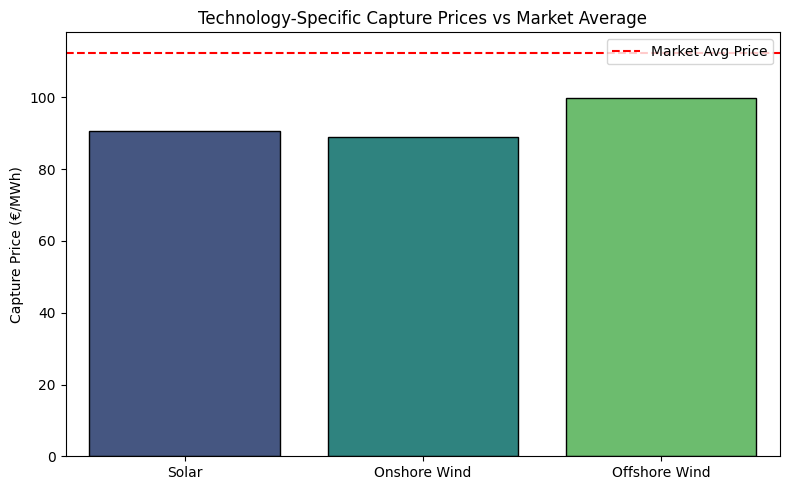

/tmp/ipykernel_64752/3470196609.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=techs, y=cannib_coeffs, palette='mako', edgecolor='black')


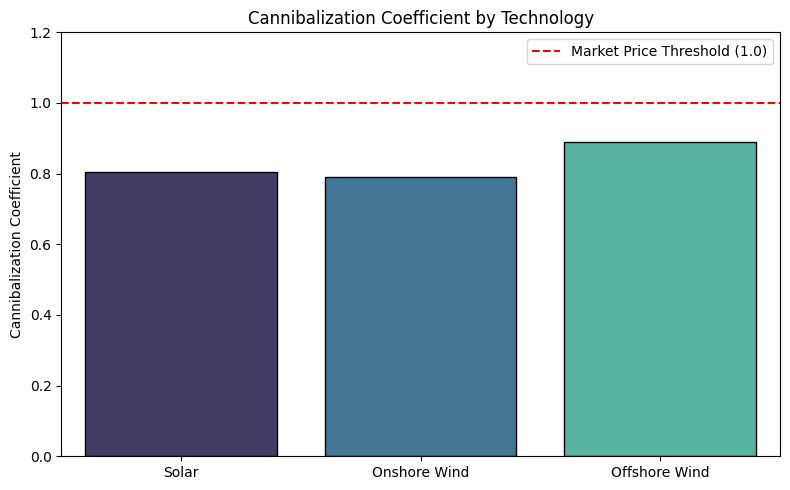

In [17]:
# --- Visualization: Capture Prices and Cannibalization Coefficient ---
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
techs = ['Solar', 'Onshore Wind', 'Offshore Wind']
capture_prices = [solar_cp, onshore_cp, offshore_cp]
cannib_coeffs = [solar_cannib, onshore_cannib, offshore_cannib]
market_avg = market_avg_price

# Plot Capture Prices
plt.figure(figsize=(8, 5))
sns.barplot(x=techs, y=capture_prices, palette='viridis', edgecolor='black')
plt.axhline(market_avg, color='red', linestyle='--', label='Market Avg Price')
plt.ylabel('Capture Price (€/MWh)')
plt.title('Technology-Specific Capture Prices vs Market Average')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Cannibalization Coefficient
plt.figure(figsize=(8, 5))
sns.barplot(x=techs, y=cannib_coeffs, palette='mako', edgecolor='black')
plt.axhline(1, color='red', linestyle='--', label='Market Price Threshold (1.0)')
plt.ylabel('Cannibalization Coefficient')
plt.title('Cannibalization Coefficient by Technology')
plt.ylim(0, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

The calculated capture prices for solar (90.63 €/MWh), onshore wind (89.04 €/MWh), and offshore wind (99.97 €/MWh) represent the average market prices received by each technology, weighted by their respective generation profiles. In comparison, the time-weighted average market price over the same period was 112.51 €/MWh.

The cannibalization coefficients—solar: 0.806, onshore wind: 0.791, and offshore wind: 0.889—quantify the ratio of each technology's capture price to the market average price. All coefficients are below 1, indicating that these renewable technologies consistently earn less than the average market price. This outcome is characteristic of variable renewables, which tend to generate more electricity during periods of high resource availability (e.g., sunny or windy conditions), often coinciding with lower market prices due to increased supply.

## Phase 1: COVID-19 Anomalies (2020–2021):
We will now
1. Assess the impact of industrial lockdowns on `cons_total_grid` and `cons_residual`.
2. Evaluate the frequency of negative prices in `price_de_lu` during low-demand, high-renewables periods.


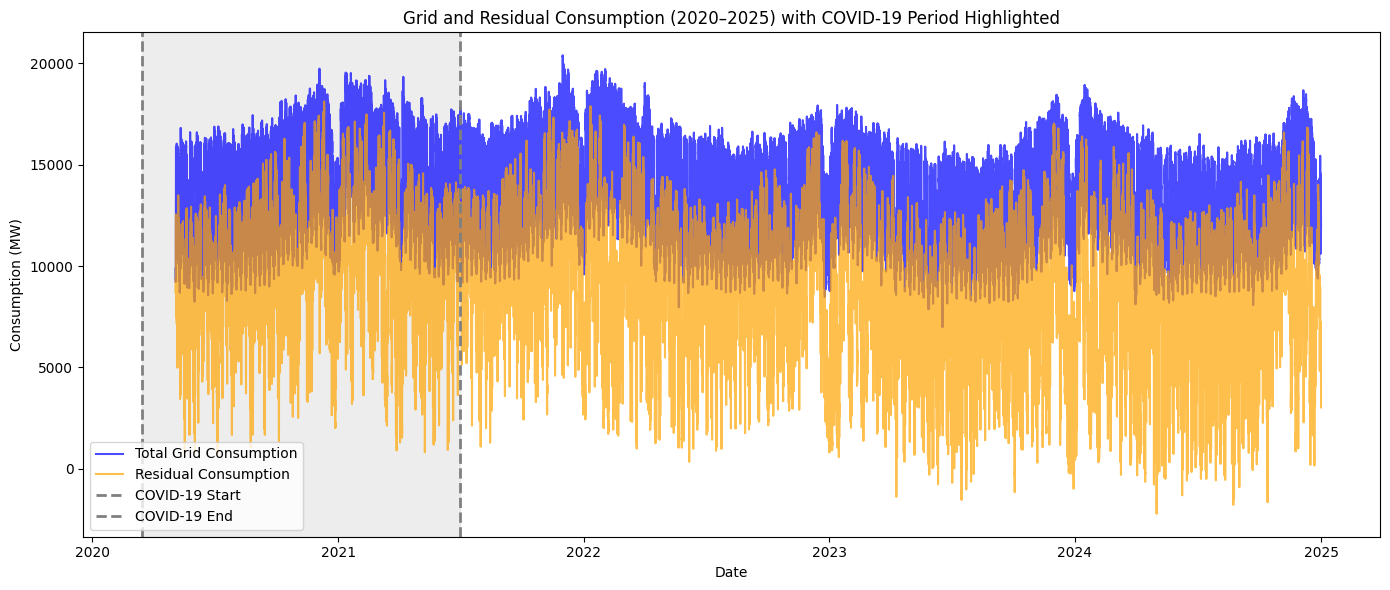

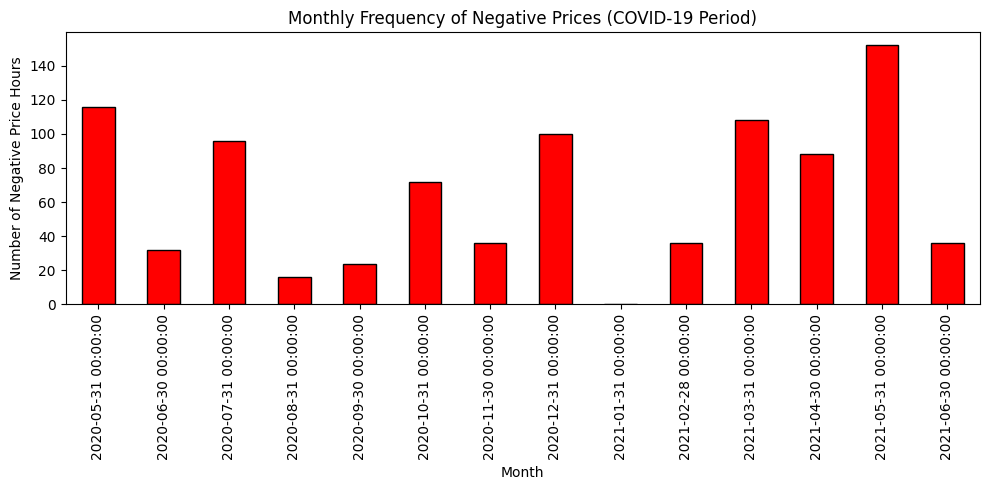

Total negative price hours during COVID-19: 912


In [22]:
# --- Phase 1: COVID-19 Anomalies (2020–2021) ---
# Plot all data from 2020-2025, highlight COVID-19 period
# Define COVID-19 start and end dates (ensure timezone-naive)
covid_start = pd.Timestamp('2020-03-15').tz_localize(None)
covid_end = pd.Timestamp('2021-06-30').tz_localize(None)
plot_start = pd.Timestamp('2020-01-01').tz_localize(None)
plot_end = pd.Timestamp('2025-01-01').tz_localize(None)
# Ensure index is timezone-naive
df_plot = df.copy()
if hasattr(df_plot.index, 'tz') and df_plot.index.tz is not None:
    df_plot.index = df_plot.index.tz_localize(None)
# Filter for plotting range
df_plot = df_plot.loc[(df_plot.index >= plot_start) & (df_plot.index < plot_end)]
# Plot total and residual consumption
plt.figure(figsize=(14, 6))
plt.plot(df_plot.index, df_plot['cons_total_grid'], label='Total Grid Consumption', color='blue', alpha=0.7)
if 'cons_residual' in df_plot.columns:
    plt.plot(df_plot.index, df_plot['cons_residual'], label='Residual Consumption', color='orange', alpha=0.7)
# Add vertical lines for COVID-19 start and end
plt.axvline(covid_start, color='grey', linestyle='--', linewidth=2, label='COVID-19 Start')
plt.axvline(covid_end, color='grey', linestyle='--', linewidth=2, label='COVID-19 End')
# Add light grey background for COVID-19 period
plt.axvspan(covid_start, covid_end, color='lightgrey', alpha=0.4, zorder=0)
plt.title('Grid and Residual Consumption (2020–2025) with COVID-19 Period Highlighted')
plt.ylabel('Consumption (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()
# 2. Frequency of negative prices during low demand/high renewables (keep original logic, but for COVID period)
df_covid = df_plot.loc[(df_plot.index >= covid_start) & (df_plot.index <= covid_end)]
negative_prices_covid = df_covid[df_covid['price_de_lu'] < 0]
neg_price_freq = negative_prices_covid.resample('ME').size()  # Use 'ME' for month end
plt.figure(figsize=(10, 5))
neg_price_freq.plot(kind='bar', color='red', edgecolor='black')
plt.title('Monthly Frequency of Negative Prices (COVID-19 Period)')
plt.ylabel('Number of Negative Price Hours')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
print(f"Total negative price hours during COVID-19: {len(negative_prices_covid)}")

## Phase 2: The Energy Crisis & Geopolitical Shock (2022–2023):
We will now
1. Analyze the structural shift when Russian gas supplies dropped. Quantify the compensation behavior of `gen_lignite`, `gen_hard_coal`, and the pricing impact on `gen_natural_gas`.
2. Map the phase-out of `gen_nuclear` (completed April 2023). View how its 25.2% missing data reflects this structural termination, and analyze which sources filled the baseload gap.


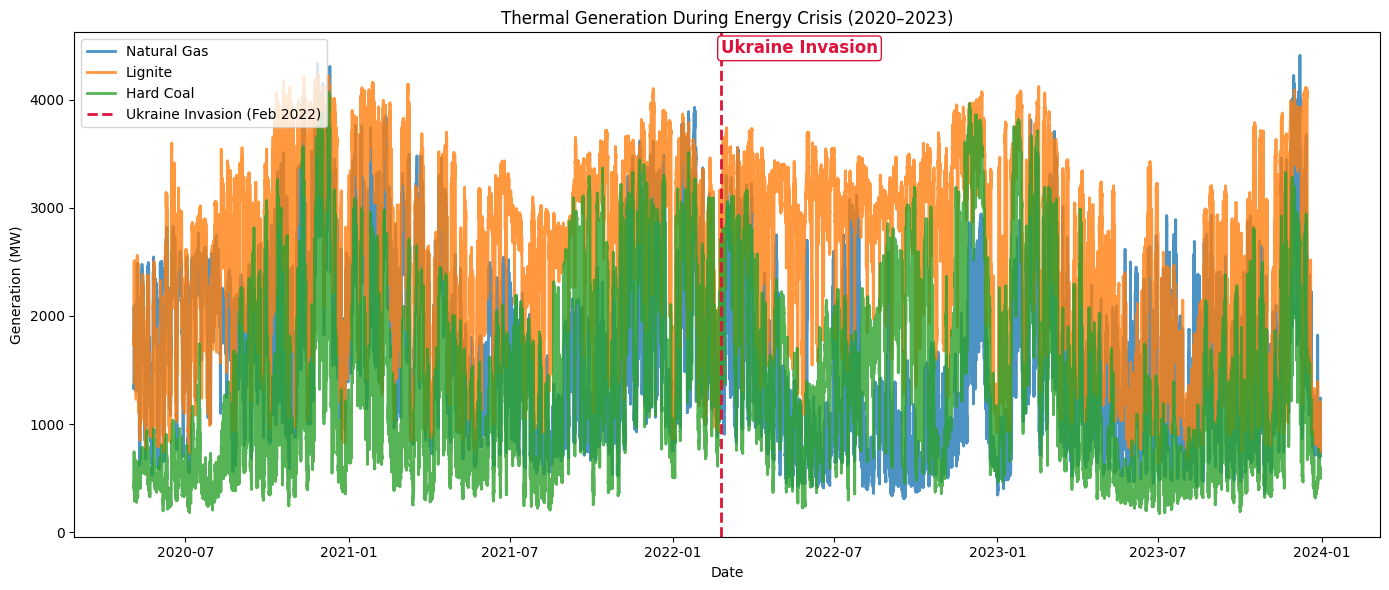

gen_lignite: Pre-crisis mean = 2854.5 MW, Post-crisis mean = 2586.6 MW, Change = -267.9 MW
gen_hard_coal: Pre-crisis mean = 1809.7 MW, Post-crisis mean = 1421.4 MW, Change = -388.3 MW
gen_natural_gas: Pre-crisis mean = 1594.0 MW, Post-crisis mean = 1332.7 MW, Change = -261.3 MW


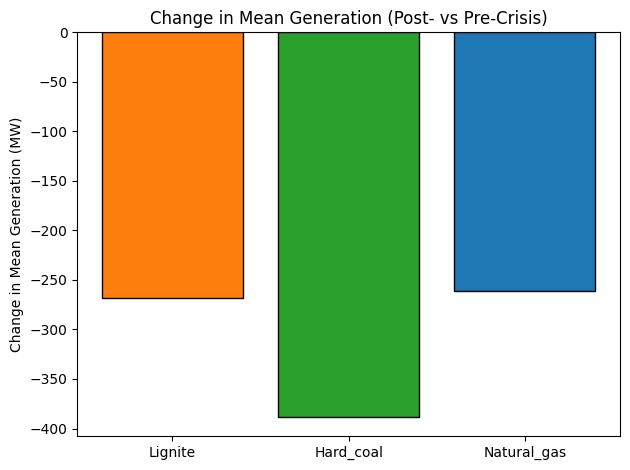

Correlation between price_de_lu and gen_natural_gas (post-crisis): 0.20
gen_nuclear missing data: 25.2% (expected due to phase-out in April 2023)


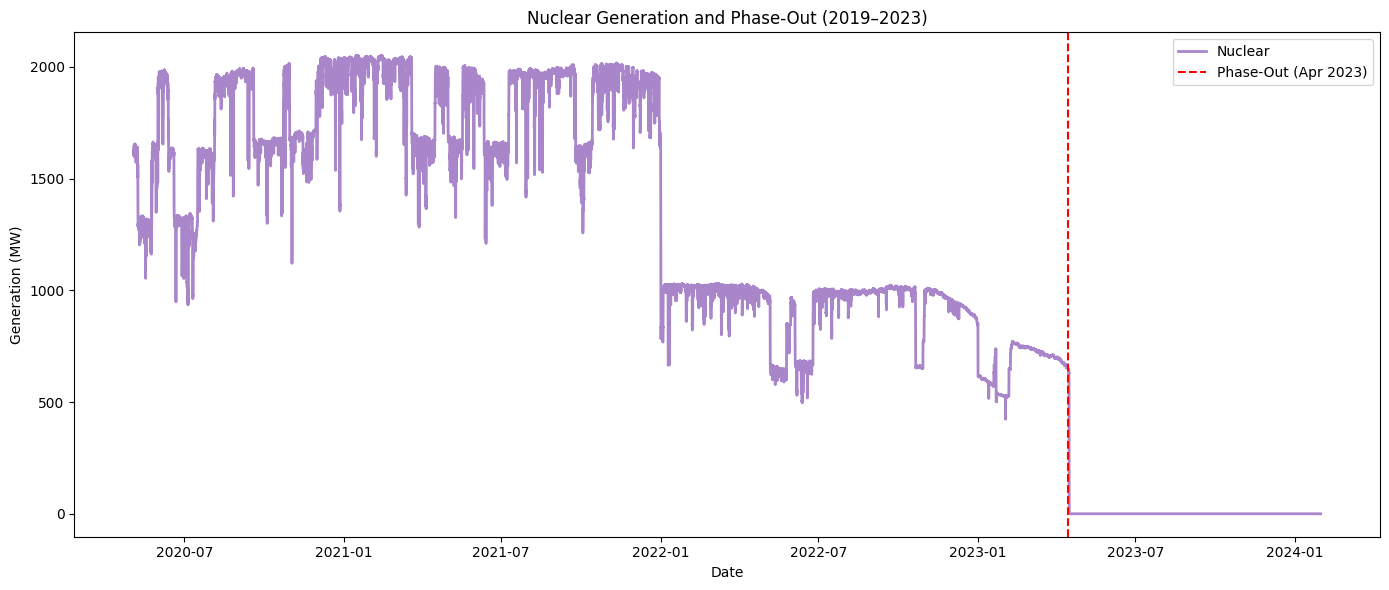

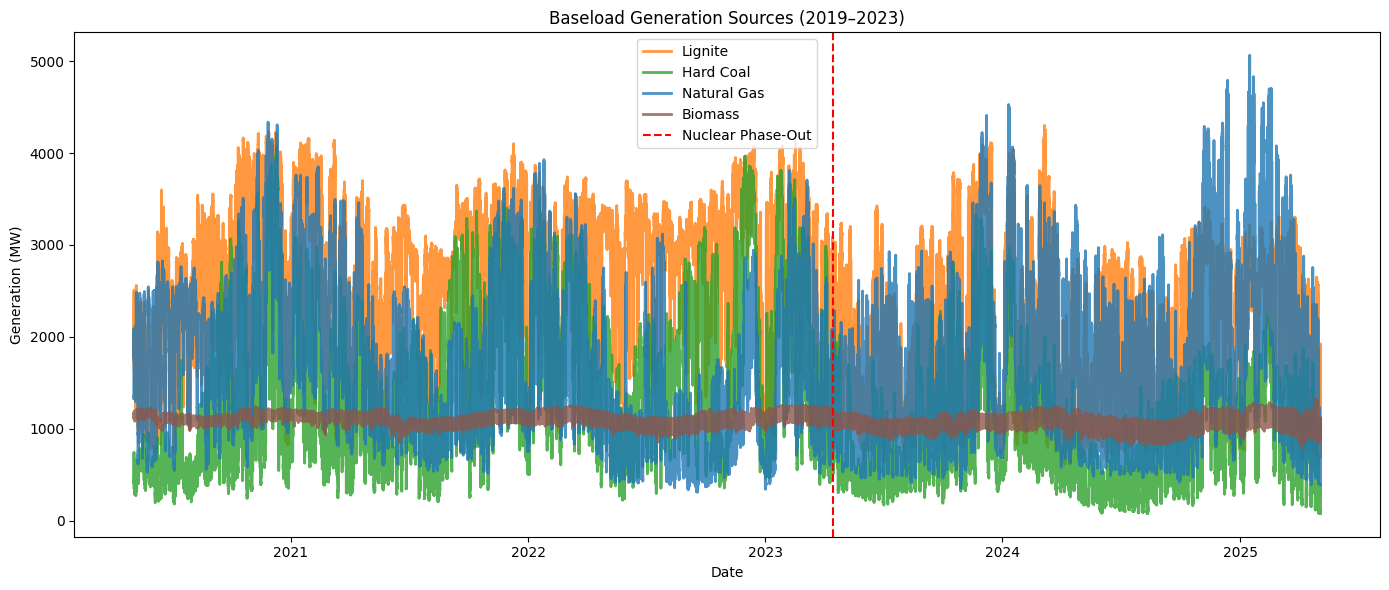

In [19]:
# --- Phase 2: The Energy Crisis & Geopolitical Shock (2022–2023) ---
# Filter for crisis period (show data since 2020 for context)
df_crisis = df.loc[(df.index >= '2020-01-01') & (df.index <= '2023-12-31')]

# 1. Structural shift: Russian gas supply drop and compensation by other sources
plt.figure(figsize=(14, 6))
plt.plot(df_crisis.index, df_crisis['gen_natural_gas'], label='Natural Gas', color='#1f77b4', alpha=0.8, linewidth=2)
plt.plot(df_crisis.index, df_crisis['gen_lignite'], label='Lignite', color='#ff7f0e', alpha=0.8, linewidth=2)
plt.plot(df_crisis.index, df_crisis['gen_hard_coal'], label='Hard Coal', color='#2ca02c', alpha=0.8, linewidth=2)
# Add vertical line for Russian invasion of Ukraine (Feb 24, 2022)
invasion_date = pd.Timestamp('2022-02-24')
plt.axvline(invasion_date, color='crimson', linestyle='--', linewidth=2, label='Ukraine Invasion (Feb 2022)')
# Add horizontal annotation for Ukraine invasion
ymin, ymax = plt.ylim()
plt.annotate('Ukraine Invasion', xy=(invasion_date, ymax*0.95), xytext=(invasion_date, ymax*0.95),
             textcoords='data', ha='left', va='bottom', color='crimson', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='crimson', lw=1),
             rotation=0,
             arrowprops=dict(arrowstyle='-|>', color='crimson', lw=1.5, shrinkA=0, shrinkB=0,
                             connectionstyle='angle,angleA=0,angleB=90,rad=0'))
plt.title('Thermal Generation During Energy Crisis (2020–2023)')
plt.ylabel('Generation (MW)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Quantify compensation: mean change before/after Feb 2022 (Ukraine invasion)
pre_crisis = df.loc[(df.index >= '2021-07-01') & (df.index < '2022-02-24')]
post_crisis = df.loc[(df.index >= '2022-02-24') & (df.index <= '2023-12-31')]
for fuel, color in zip(['gen_lignite', 'gen_hard_coal', 'gen_natural_gas'], ['#ff7f0e', '#2ca02c', '#1f77b4']):
    pre_mean = pre_crisis[fuel].mean()
    post_mean = post_crisis[fuel].mean()
    plt.bar(fuel.replace('gen_', '').capitalize(), post_mean - pre_mean, color=color, edgecolor='black')
    print(f"{fuel}: Pre-crisis mean = {pre_mean:.1f} MW, Post-crisis mean = {post_mean:.1f} MW, Change = {post_mean - pre_mean:.1f} MW")
plt.title('Change in Mean Generation (Post- vs Pre-Crisis)')
plt.ylabel('Change in Mean Generation (MW)')
plt.tight_layout()
plt.show()

# Pricing impact on natural gas
gas_price_impact = post_crisis['price_de_lu'].corr(post_crisis['gen_natural_gas'])
print(f"Correlation between price_de_lu and gen_natural_gas (post-crisis): {gas_price_impact:.2f}")

# 2. Nuclear phase-out analysis
nuclear_missing_pct = df['gen_nuclear'].isna().mean() * 100
print(f"gen_nuclear missing data: {nuclear_missing_pct:.1f}% (expected due to phase-out in April 2023)")

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['gen_nuclear'], label='Nuclear', color='#9467bd', alpha=0.8, linewidth=2)
plt.axvline(pd.Timestamp('2023-04-15'), color='red', linestyle='--', label='Phase-Out (Apr 2023)')
plt.title('Nuclear Generation and Phase-Out (2019–2023)')
plt.ylabel('Generation (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# Baseload gap compensation: plot main baseload sources
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['gen_lignite'], label='Lignite', color='#ff7f0e', alpha=0.8, linewidth=2)
plt.plot(df.index, df['gen_hard_coal'], label='Hard Coal', color='#2ca02c', alpha=0.8, linewidth=2)
plt.plot(df.index, df['gen_natural_gas'], label='Natural Gas', color='#1f77b4', alpha=0.8, linewidth=2)
plt.plot(df.index, df['gen_biomass'], label='Biomass', color='#8c564b', alpha=0.8, linewidth=2)
plt.axvline(pd.Timestamp('2023-04-15'), color='red', linestyle='--', label='Nuclear Phase-Out')
plt.title('Baseload Generation Sources (2019–2023)')
plt.ylabel('Generation (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


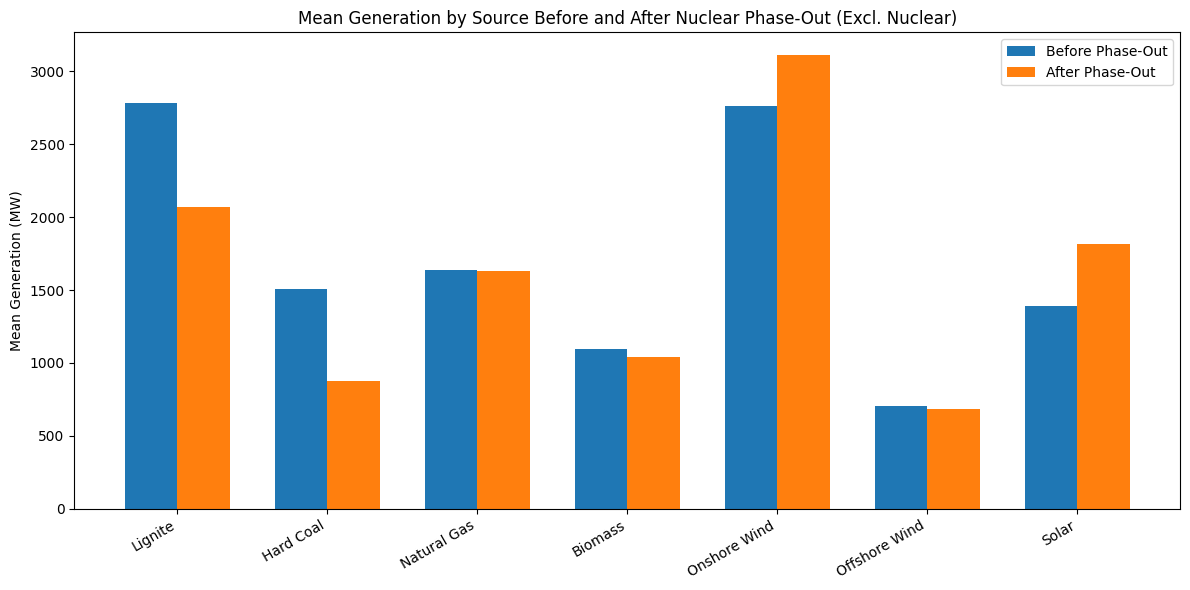

In [20]:
# --- Generation Mix Before vs After Nuclear Phase-Out (Excluding Nuclear) ---
# Define phase-out date (ensure timezone-naive)
phaseout_date = pd.Timestamp('2023-04-15').tz_localize(None)
# Ensure index is timezone-naive
df_index_naive = df.copy()
if hasattr(df_index_naive.index, 'tz') and df_index_naive.index.tz is not None:
    df_index_naive.index = df_index_naive.index.tz_localize(None)
# Choose main generation sources to compare (excluding nuclear)
sources = ['gen_lignite', 'gen_hard_coal', 'gen_natural_gas', 'gen_biomass', 'gen_onshore_wind', 'gen_offshore_wind', 'gen_solar']
# Calculate mean generation before and after phase-out
before = df_index_naive.loc[df_index_naive.index < phaseout_date, sources].mean()
after = df_index_naive.loc[df_index_naive.index >= phaseout_date, sources].mean()
# Prepare DataFrame for plotting
import numpy as np
import matplotlib.pyplot as plt
labels = [s.replace('gen_', '').replace('_', ' ').title() for s in sources]
x = np.arange(len(sources))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, before.values, width, label='Before Phase-Out', color='#1f77b4')
rects2 = ax.bar(x + width/2, after.values, width, label='After Phase-Out', color='#ff7f0e')
ax.set_ylabel('Mean Generation (MW)')
ax.set_title('Mean Generation by Source Before and After Nuclear Phase-Out (Excl. Nuclear)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()